In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
sample_df = pd.read_csv(
    "../data/processed/sample_dataset.csv"
)

sample_df.head()

,heading,news_body,category
0,नेप्से र कारोबार रकम दुवै घट्यो,काठमाडौं — आइतबार र सोमबार उच्च अंकले बढेको ने...,business
1,लुम्बिनी घुम्न निम्तो,काठमाडौँ — यो वर्ष प्रदेश ५ ले लुम्बिनीमा सकेक...,business
2,कृषि अनुदान ‘दुरुपयोग’,काठमाडौँ — रुकुमका राजकुमार बुढामगर पेसाले किस...,business
3,नेपाल-चीन भन्सार २६ औं बैठक,धुलिखेल — नेपाल-चीनका भन्सार अधिकारीहरूको वषिर...,business
4,चियाका समस्या सम्बोधन गर्न कार्यदल,काठमाडौ — मुलुककै सबैभन्दा पुरानो निर्यातयोग्य...,business


In [3]:
sample_df.shape

(96000, 3)

In [4]:
sample_df.columns

Index(['heading', 'news_body', 'category'], dtype='str')

In [5]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   heading    95840 non-null  str  
 1   news_body  96000 non-null  str  
 2   category   96000 non-null  str  
dtypes: str(3)
memory usage: 437.6 MB


In [6]:
sample_df.describe(include="all")

,heading,news_body,category
count,95840,96000,96000
unique,94768,95969,12
top,राशिअनुसार आजको आफ्नो भाग्य हेर्नुहोस्,हेर्नुहोस् कालिमाटी फलफूल तथा तरकारी बजारमा आज...,business
freq,51,3,8000


In [7]:
sample_df.memory_usage(deep=True).sum()/1024**2

np.float64(437.5776672363281)

In [8]:
sample_df.isnull().sum()

heading      160
news_body      0
category       0
dtype: int64

In [9]:
(
    sample_df
    .isnull()
    .mean()
    *100
).round(2)

heading      0.17
news_body    0.00
category     0.00
dtype: float64

In [10]:
sample_df.duplicated().sum()

np.int64(17)

In [11]:
sample_df["heading"].duplicated().sum()

np.int64(1231)

In [12]:
sample_df["news_body"].duplicated().sum()

np.int64(31)

In [13]:
sample_df["category"].value_counts()

category
business                  8000
crime                     8000
economy                   8000
education                 8000
entertainment             8000
global                    8000
health                    8000
national                  8000
politics                  8000
science and technology    8000
society                   8000
sports                    8000
Name: count, dtype: int64

In [14]:
(
    sample_df["category"]
    .value_counts(normalize=True)
    *100
).round(2)

category
business                  8.33
crime                     8.33
economy                   8.33
education                 8.33
entertainment             8.33
global                    8.33
health                    8.33
national                  8.33
politics                  8.33
science and technology    8.33
society                   8.33
sports                    8.33
Name: proportion, dtype: float64

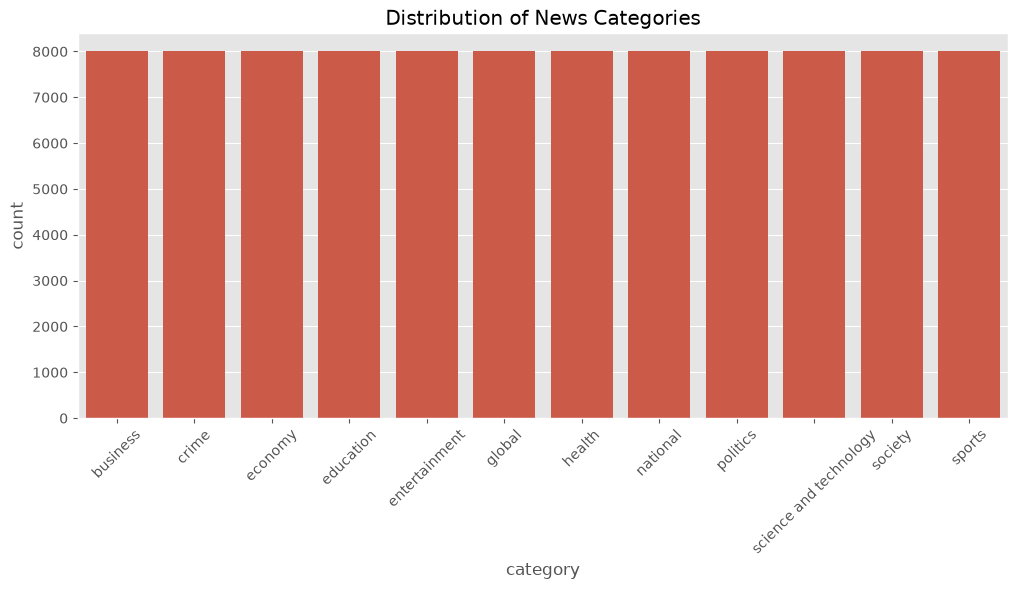

In [15]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=sample_df,
    x="category",
    order=sample_df["category"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of News Categories")

plt.show()

In [16]:
sample_df["char_length"] = (
    sample_df["news_body"]
    .str.len()
)

In [17]:
sample_df["char_length"].describe()

count     96000.000000
mean       1728.930146
std        3445.730991
min           7.000000
25%         732.000000
50%        1183.000000
75%        2103.000000
max      509480.000000
Name: char_length, dtype: float64

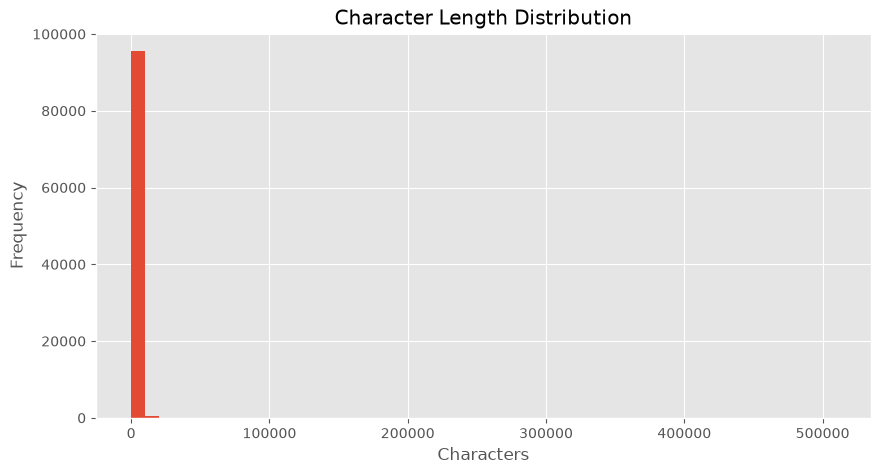

In [18]:
plt.figure(figsize=(10,5))

plt.hist(
    sample_df["char_length"],
    bins=50
)

plt.title("Character Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [19]:
sample_df["word_count"] = (
    sample_df["news_body"]
    .str.split()
    .str.len()
)

In [20]:
sample_df["word_count"].describe()

count    96000.000000
mean       264.985125
std        528.790638
min          1.000000
25%        113.000000
50%        182.000000
75%        321.000000
max      78486.000000
Name: word_count, dtype: float64

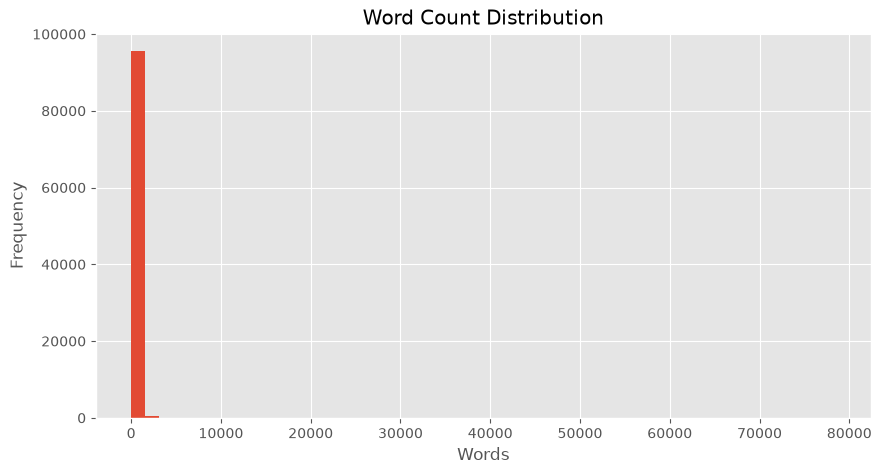

In [21]:
plt.figure(figsize=(10,5))

plt.hist(
    sample_df["word_count"],
    bins=50
)

plt.title("Word Count Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [22]:
sample_df.groupby("category")["word_count"].mean().sort_values()

category
crime                     160.712250
global                    215.212875
entertainment             217.059375
sports                    221.563125
national                  252.395875
economy                   266.215875
politics                  272.410750
society                   281.917000
science and technology    288.535125
education                 305.103375
business                  341.460375
health                    357.235500
Name: word_count, dtype: float64

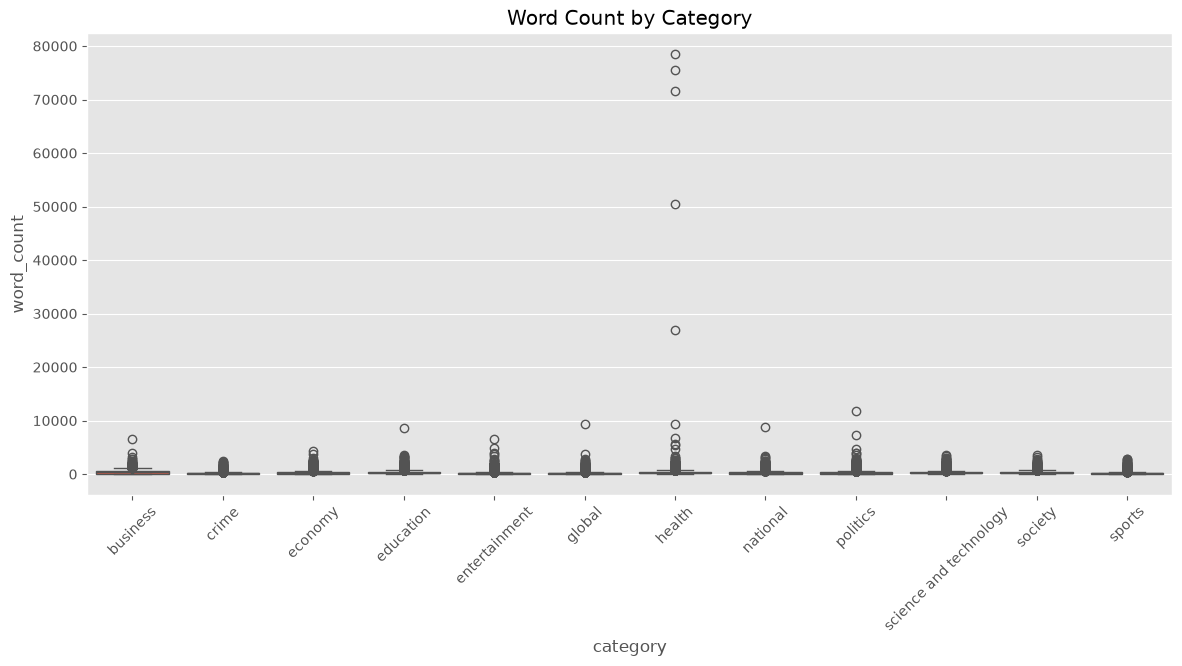

In [23]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=sample_df,
    x="category",
    y="word_count"
)

plt.xticks(rotation=45)

plt.title("Word Count by Category")

plt.show()

In [24]:
sample_df.nlargest(
    10,
    "char_length"
)[["heading","category","char_length"]]

,heading,category,char_length
54619,११ हजार एक सय ६२ कोरोना भाइरसका संक्रमित को को...,health,509480
50458,१० हजार ९९ कोरोना भाइरसका संक्रमित को को (विवर...,health,489850
52323,९५६१ कोरोना भाइरसका संक्रमित को को (विवरणसहित),health,465511
50127,नेपालका ६ हजार ५ सय ९१ कोरोना भाइरसका संक्रमित...,health,328800
49640,१३ मृतकसहित ३२३५ कोरोना भाइरसका संक्रमित को को...,health,176751
71652,यस्ता छन् प्रत्यक्षतर्फ एमालेबाट निर्वाचित ८० ...,politics,76529
44189,"अयोध्या : रक्तपातपूर्ण इतिहास, विवादको भुमरीमा...",global,63110
58935,कर्णाली प्रदेश सरकारको बजेट सार्वजनिक (पूर्णपा...,national,61617
55948,८८६ कोरोना भाइरसका संक्रमित को को (विवरणसहित),health,58532
26114,के हो नागरिक समाज ? के हुन् यसका शक्ति र सीमा ?,education,56407


In [25]:
sample_df.loc[
    sample_df["char_length"]>10000,
    ["heading","category","char_length"]
]

,heading,category,char_length
137,कस्तो छ डिजिटल पूर्वाधार ?,business,14069
192,स्थानीय तहको बजेट : कोरोना रोकथामकै वरिपरि,business,21610
450,पर्यटनमा कोरोना प्रभाव : मासिक १० अर्बको क्षति,business,15490
462,नेपाल–बंगलादेश व्यापारका दुई दशक,business,12712
836,गौरवका आयोजनाको प्रगति निराशाजनक,business,12916
...,...,...,...
92782,आरसीटी अर्थात् फुटबलको जिउँदो इतिहास [भिडियो र...,sports,17667
93429,खेतमा खेलाइने प्रतियोगिता पनि गोल्डकप!,sports,10157
94791,काठमाडौं रेजर्स : यात्रा ऐतिहासिक नेपाल सुपर ल...,sports,13499
94915,"अक्सनपछि यस्तो बने आइएपिएलका ८ टिम, को कहाँ आब...",sports,14113


In [26]:
sample_df["word_count"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     542.000
0.950     714.000
0.990    1232.000
0.995    1544.000
0.999    2410.031
Name: word_count, dtype: float64

In [27]:
print((sample_df["word_count"] > 1000).sum())

print((sample_df["word_count"] > 2000).sum())

print((sample_df["word_count"] > 5000).sum())

print((sample_df["word_count"] > 10000).sum())

1859
192
16
6


In [28]:
sample_df["news_body"].str.contains(
    r"http|https|www",
    regex=True,
    na=False
).sum()

np.int64(569)

In [29]:

sample_df["news_body"].str.contains(
    r"<.*?>",
    regex=True,
    na=False
).sum()

np.int64(9)

In [30]:
(sample_df["heading"].fillna("").str.strip() == "").sum()

np.int64(160)

In [31]:
sample_df["news_body"].sample(20, random_state=42)

83250    ललितपुर– बिष्णुडोल खानेपानी आयोजनाको क्षमता अभ...
71978    ईश्वर थापा- ईश्वर थापा- धनकुटा : आगामी असार १४...
47489    सोल, वैशाख २ । दक्षिण कोरियामा भएको संसदीय निर...
94910    काठमाण्डाै - एमसीसीविरुद्धको तीन दिवसीय खेलको ...
18844    कात्तिक १९, काठमाडौं । लामो समयदेखि नाफा कमाउँ...
64622    काठमाडौँ– कपिलवस्तुको चन्द्रौटामा सशस्त्र प्रह...
6662     काठमाडौँ — ललितपुर बाँडेगाउँका हेराकाजी महर्जन...
63817    इलाम (मङ्गलबारे) — इलाम नगरपालिका–३ मा रहेको प...
65648    विवेकशील साझा पार्टीका संयोजक मिलन पाण्डेले प्...
3022     कास्की — सरकारले हालै घोषणा गरेको नयाँ पर्यटकी...
28193    काठमाडौं – कृषि तथा वन विश्वविद्यालयका पदाधिका...
57816    (सन्दकपुर, इलाम) — हुस्सुले छपक्कै छोपेको दिन ...
47932    काठमाण्डाै - बङ्गलादेशमा चट्याङ्ग लाग्दा १७ जन...
35023    काठमाडौं–‘मिस टिन एसईई २०१९’का प्रतिस्पर्धीहरु...
88374    कमेडी च्याम्पियन सिजन २ का विजेता भरतमणि पौडेल...
60075    धनगढी । सुदूरपश्चिम प्रदेश सरकारका दुई मन्त्री...
66283    विभिन्न संवैधानिक निकायमा सिफारिस भएका पदाधिका.